<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
pip install numpy pandas matplotlib

**Import Dataset from Kaggle**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression


**Check first 5 rows**

In [ ]:
import pandas as pd

df = pd.read_csv(path + "/Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

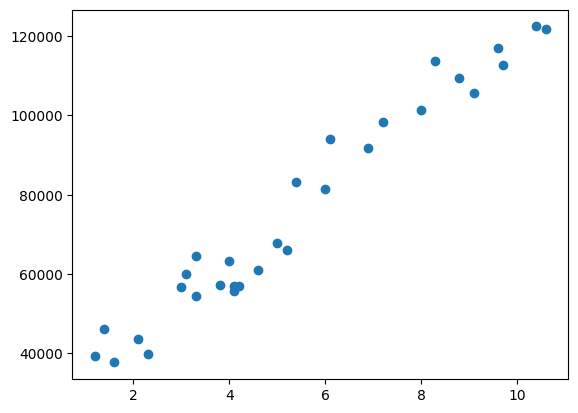

In [ ]:
plt.scatter(df['YearsExperience'],df['Salary'])

In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

Defining x and y

In [ ]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [ ]:
X

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [ ]:
y

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0
5,56643.0
6,60151.0
7,54446.0
8,64446.0
9,57190.0


Splitiing x and y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
X_test

,YearsExperience
27,9.7
15,5.0
23,8.3
17,5.4
8,3.3
9,3.8


In [ ]:
y_test

,Salary
27,112636.0
15,67939.0
23,113813.0
17,83089.0
8,64446.0
9,57190.0


In [ ]:
model.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([115791.21011287])

In [ ]:
model.predict(X_test.iloc[1].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71499.27809463])

Text(0, 0.5, 'Salary')

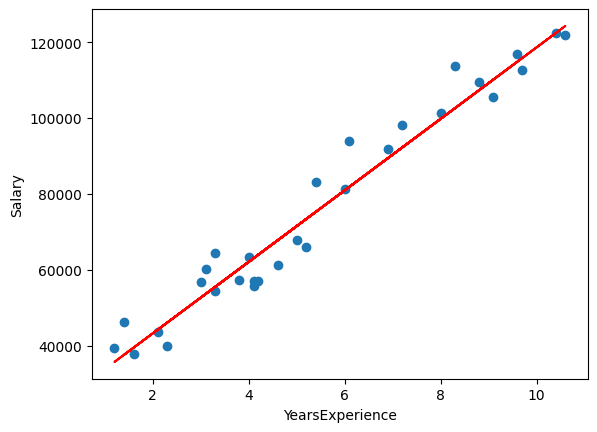

In [ ]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.plot(X_train, model.predict(X_train), color='red')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

In [ ]:
m = model.coef_

In [ ]:
c = model.intercept_

In [ ]:
# y = mx +c
m * 9.7 + c

array([115791.21011287])

In [ ]:
y_pred = model.predict(X_test)

**Evaluation Metrics**

In [ ]:
from sklearn.metrics import mean_absolute_error


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 6286.453830757745


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 49830096.855908394


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 7059.04362190151


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9024461774180497


# **Multiple Linear Regression**

In [ ]:
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "CarPrice_Assignment.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "hellbuoy/car-price-prediction",
    file_path,
)

print(df.head())

/tmp/ipykernel_7275/1788046383.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'car-price-prediction' dataset.
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fu

In [ ]:
print(df.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


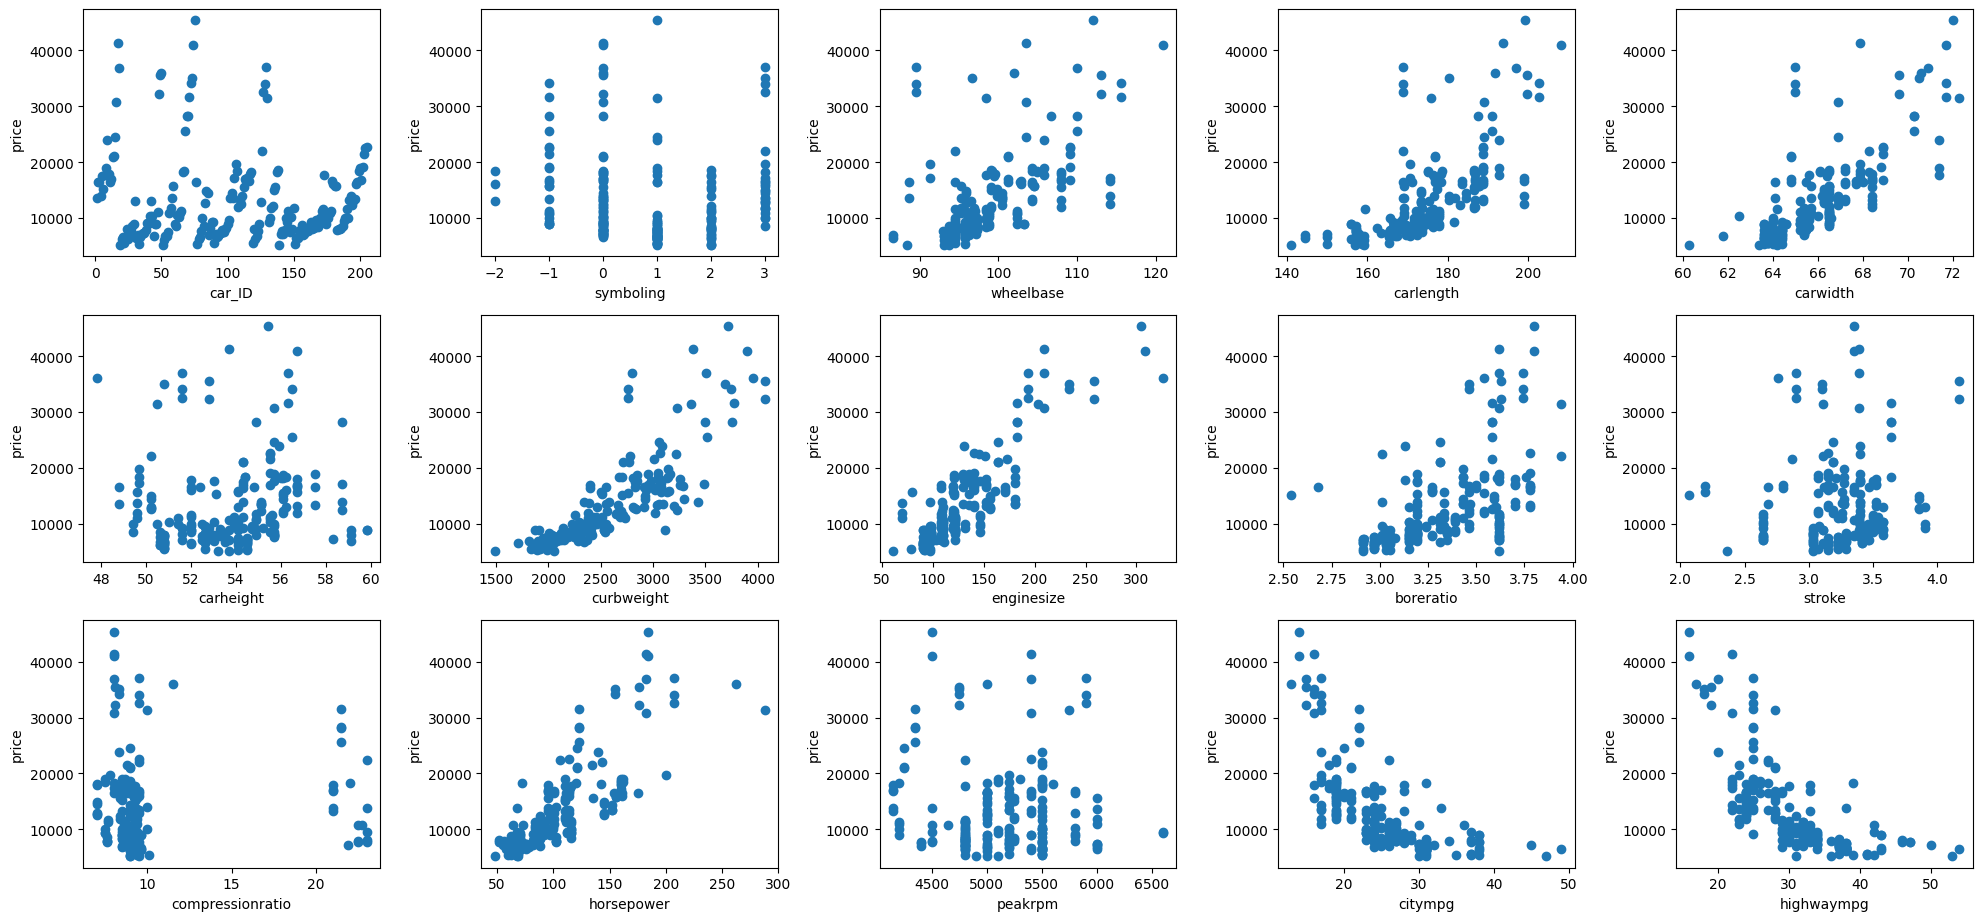

In [ ]:
import matplotlib.pyplot as plt

# ✅ define cols FIRST
cols = df.select_dtypes(include=['int64', 'float64']).columns
cols = cols.drop('price')

plt.figure(figsize=(20, 15))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 5, i)
    plt.scatter(df[col], df['price'])
    plt.xlabel(col)
    plt.ylabel('price')

plt.tight_layout()
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(corr)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
car_ID             -0.109093
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['enginesize','horsepower','curbweight','carwidth']]
y = df['price']


In [ ]:
X.head()

,enginesize,horsepower,curbweight,carwidth
0,130,111,2548,64.1
1,130,111,2548,64.1
2,152,154,2823,65.5
3,109,102,2337,66.2
4,136,115,2824,66.4


In [ ]:
y.head()

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
X_train

,enginesize,horsepower,curbweight,carwidth
66,134,72,2700,66.1
111,120,95,3075,68.4
153,92,62,2280,63.6
96,97,69,1971,63.8
38,110,86,2289,65.2
...,...,...,...,...
106,181,160,3139,67.9
14,164,121,3055,66.9
92,97,69,1938,63.8
179,171,161,3016,67.7


In [ ]:
y_train

,price
66,18344.0
111,15580.0
153,6918.0
96,7499.0
38,9095.0
...,...
106,18399.0
14,24565.0
92,6849.0
179,15998.0


In [ ]:
model.predict(X_test)

array([25823.02332068, 18798.77699226, 11334.76742652, 13652.30837798,
       23815.77993835,  6599.12018528,  7802.46460977,  7335.19707722,
       10675.00343923,  7226.64060698, 15081.06806466,  7218.23190669,
       15450.48629923, 12263.2566441 , 38044.53888245,  5681.6514918 ,
        -633.86862651, 18502.14899316, 11345.92408828, 10437.9185149 ,
       11826.44851215, 21497.84712486,  6557.88802453,  5031.44607823,
        5917.43609645, 26754.53473867, 15118.28157717, 16642.23203551,
        6617.67465762, 16390.71585492, 23331.30204951,  5872.08071962,
        6248.59370215, 21229.96272809,  8686.38978918, 23290.06988875,
       11699.08549336,  8108.76621743,  5735.19383592, 18693.87854067,
        9691.99556332])

In [ ]:
X_test.head()

,enginesize,horsepower,curbweight,carwidth
15,209,182,3230,66.9
9,131,160,3053,67.9
100,120,97,2302,65.2
132,121,110,2658,66.5
68,183,123,3750,70.3


In [ ]:
y_test.head()

,price
15,30760.000
9,17859.167
100,9549.000
132,11850.000
68,28248.000


In [ ]:
model.predict(X_test.iloc[0].values.reshape(1, -1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([25823.02332068])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8200839678407296


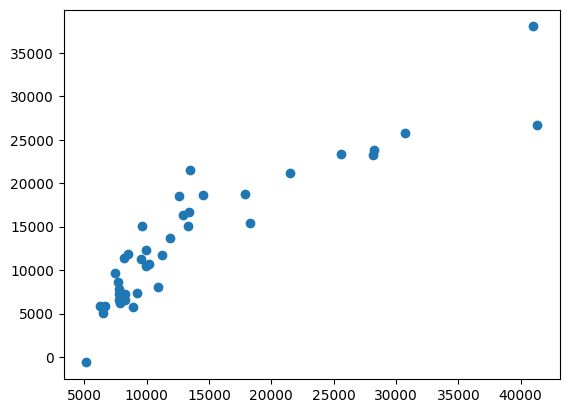

In [ ]:
plt.scatter(y_test, model.predict(X_test))

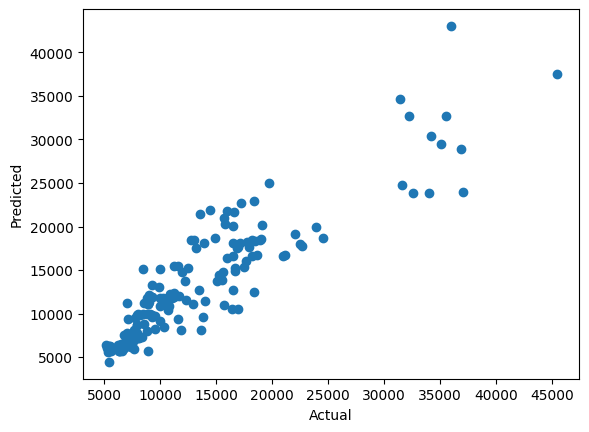

In [ ]:
plt.scatter(y_train, model.predict(X_train))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

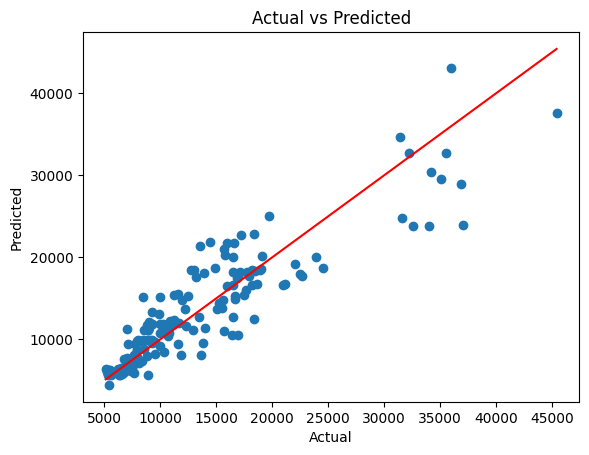

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_train)

plt.scatter(y_train, y_pred)

# perfect prediction line
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()